In [34]:
# =============================
# 1) Imports et configuration
# =============================

import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# Pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


In [35]:
# =====================================
# 2) Chargement des données depuis CSV
# =====================================

CSV_PATH = "../data_folder/cache/BTC-USD.csv"  # <-- A adapter


# Lecture CSV
raw_df = pd.read_csv(CSV_PATH)

raw_df.head()

df = raw_df.copy()


In [36]:
'''# Copie de travail
df = raw_df.copy()

# Conversion en datetime + tri chronologique
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# Option pertinente pour une série temporelle: date comme index
df = df.set_index("date")

# Tri de sécurité sur l'index temporel
df = df.sort_index()

print("Shape du dataset:", df.shape)
print("Période:", df.index.min(), "->", df.index.max())'''

'# Copie de travail\ndf = raw_df.copy()\n\n# Conversion en datetime + tri chronologique\ndf["date"] = pd.to_datetime(df["date"], errors="coerce")\ndf = df.sort_values("date").reset_index(drop=True)\n\n# Option pertinente pour une série temporelle: date comme index\ndf = df.set_index("date")\n\n# Tri de sécurité sur l\'index temporel\ndf = df.sort_index()\n\nprint("Shape du dataset:", df.shape)\nprint("Période:", df.index.min(), "->", df.index.max())'

In [37]:
# ======================================
# 3) Aperçu, types et valeurs manquantes
# ======================================

print("\nAperçu des données:")
display(df.head())

print("\nTypes de colonnes:")
print(df.dtypes)

print("\nValeurs manquantes par colonne:")
print(df.isna().sum())

print("\nStatistiques descriptives:")
display(df.describe().T)


Aperçu des données:


,Date,Open,High,Low,Close,Volume
0,2016-04-24,450.559998,460.145996,448.928009,458.554993,68198400
1,2016-04-25,459.121002,466.619995,453.592010,461.425995,87091800
2,2016-04-26,461.648010,467.964996,461.621002,466.088989,78971904
3,2016-04-27,466.261993,467.079010,444.134003,444.687012,93564896
4,2016-04-28,445.037994,449.550995,436.649994,449.010986,74064704



Types de colonnes:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Valeurs manquantes par colonne:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
Open,3650.0,3.256635e+04,3.257906e+04,4.377930e+02,6.960144e+03,2.014414e+04,5.208554e+04,1.247521e+05
High,3650.0,3.321749e+04,3.312038e+04,4.434270e+02,7.168180e+03,2.044410e+04,5.328055e+04,1.261981e+05
Low,3650.0,3.187511e+04,3.199549e+04,4.366500e+02,6.790648e+03,1.968921e+04,5.084051e+04,1.231960e+05
Close,3650.0,3.258597e+04,3.258216e+04,4.387150e+02,6.969013e+03,2.016011e+04,5.214239e+04,1.247525e+05
Volume,3650.0,2.572554e+10,2.285909e+10,2.851400e+07,6.902335e+09,2.218633e+10,3.709216e+10,3.509679e+11


In [38]:
# =====================
# 4) Création de target
# =====================

horizon = 2  # Nombre de jours dans le futur

# Si close futur > close actuel => target=1, sinon 0
# Note: le dernier(s) point(s) n'a/ont pas de close futur, donc target sera NaN.
df["target"] = (df["Close"].shift(-horizon) > df["Close"]).astype(float)

# On regarde rapidement la distribution de la classe
print("Distribution target (avant dropna final):")
print(df["target"].value_counts(dropna=False))

Distribution target (avant dropna final):
target
1.0    1970
0.0    1680
Name: count, dtype: int64


# Features engineering

In [39]:
# ==============================================
# 5) Fonctions de features techniques (pipeline)
# ==============================================

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Calcul simple du RSI (Relative Strength Index)."""
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Moyennes mobiles des gains/pertes
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / (avg_loss + 1e-12)  # epsilon pour stabilité numérique
    rsi = 100 - (100 / (1 + rs))
    return rsi


def build_technical_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Transforme un DataFrame OHLCV brut en features techniques.

    Important:
    - on travaille uniquement avec informations présentes au temps t
    - pas d'information future utilisée dans les features
    """
    data = X.copy()

    # S'assure que l'ordre temporel est correct
    data = data.sort_index()

    # MAs de base
    data["ma10"] = data["Close"].rolling(10).mean()
    data["ma30"] = data["Close"].rolling(30).mean()
    data["ma50"] = data["Close"].rolling(50).mean()
    data["ma200"] = data["Close"].rolling(200).mean()

    # 1) pente MA200 (variation relative sur 5 jours)
    data["slope_ma200_5d"] = data["ma200"].pct_change(5)

    # 2) MA50
    data["ma50_level"] = data["ma50"]

    # 3) distance spot / MA30
    data["dist_spot_ma30"] = (data["Close"] / (data["ma30"] + 1e-12)) - 1

    # 4) distance spot / MA50
    data["dist_spot_ma50"] = (data["Close"] / (data["ma50"] + 1e-12)) - 1

    # 5) crossover MA10 / MA200
    data["ma10_200_crossover"] = (data["ma10"] / (data["ma200"] + 1e-12)) - 1

    # 6) RSI
    data["rsi14"] = compute_rsi(data["Close"], window=14)

    # 7) volatility ratio 30 / 200
    daily_ret = data["Close"].pct_change()
    vol30 = daily_ret.rolling(30).std()
    vol200 = daily_ret.rolling(200).std()
    data["vol_ratio_30_200"] = vol30 / (vol200 + 1e-12)

    # Features additionnelles
    data["ret_1d"] = daily_ret
    data["mom_5d"] = data["Close"].pct_change(5)
    data["mom_10d"] = data["Close"].pct_change(10)
    data["mom_20d"] = data["Close"].pct_change(20)
    data["daily_range"] = (data["High"] - data["Low"]) / (data["Close"] + 1e-12)
    data["dist_spot_ma200"] = (data["Close"] / (data["ma200"] + 1e-12)) - 1
    data["slope_ma50_5d"] = data["ma50"].pct_change(5)
    data["volume_change_1d"] = data["Volume"].pct_change(1)
    data["rolling_vol_20"] = daily_ret.rolling(20).std()

    # Colonnes finales utilisées par le modèle
    feature_cols = [
        "slope_ma200_5d",
        "ma50_level",
        "dist_spot_ma30",
        "dist_spot_ma50",
        "ma10_200_crossover",
        "rsi14",
        "vol_ratio_30_200",
        "ret_1d",
        "mom_5d",
        "mom_10d",
        "mom_20d",
        "daily_range",
        "dist_spot_ma200",
        "slope_ma50_5d",
        "volume_change_1d",
        "rolling_vol_20",
    ]

    return data[feature_cols]

## 5) Préparation `X` / `y` + split chronologique

In [40]:
df.head()

,Date,Open,High,Low,Close,Volume,target
0,2016-04-24,450.559998,460.145996,448.928009,458.554993,68198400,1.0
1,2016-04-25,459.121002,466.619995,453.592010,461.425995,87091800,0.0
2,2016-04-26,461.648010,467.964996,461.621002,466.088989,78971904,0.0
3,2016-04-27,466.261993,467.079010,444.134003,444.687012,93564896,1.0
4,2016-04-28,445.037994,449.550995,436.649994,449.010986,74064704,0.0


In [41]:
# ==================================================
# 6) Construction de X/y et split temporel explicite
# ==================================================

# Entrées brutes pour le transformer
raw_feature_cols = ["Open", "High", "Low", "Close", "Volume"]
X_raw = df[raw_feature_cols].copy()
y_raw = df["target"].copy()

# Calcul temporaire des features pour trouver les lignes exploitables
X_feat_tmp = build_technical_features(X_raw)

# On conserve uniquement les lignes où features + target sont définies
valid_mask = X_feat_tmp.notna().all(axis=1) & y_raw.notna()
X_raw_clean = X_raw.loc[valid_mask].copy()
y_clean = y_raw.loc[valid_mask].astype(int).copy()

print("Nombre d'observations valides:", len(X_raw_clean))
print("Distribution target finale:")
print(y_clean.value_counts(normalize=True).rename("ratio"))

# Split chronologique (80% train / 20% test)
split_ratio = 0.8
split_idx = int(len(X_raw_clean) * split_ratio)

X_train = X_raw_clean.iloc[:split_idx].copy()
X_test = X_raw_clean.iloc[split_idx:].copy()
y_train = y_clean.iloc[:split_idx].copy()
y_test = y_clean.iloc[split_idx:].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nPériodes:")
print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test :", X_test.index.min(), "->", X_test.index.max())

Nombre d'observations valides: 3446
Distribution target finale:
target
1    0.538015
0    0.461985
Name: ratio, dtype: float64

Shapes:
X_train: (2756, 5) | y_train: (2756,)
X_test : (690, 5) | y_test : (690,)

Périodes:
Train: 204 -> 2959
Test : 2960 -> 3649


# Date pivot

In [42]:
index_pivot = df.index[split_idx]
print("\nDate de pivot (train/test):", index_pivot)



Date de pivot (train/test): 2756


In [43]:
date_pivot = df.Date[split_idx]
print("\nDate de pivot (train/test):", date_pivot)


Date de pivot (train/test): 2023-11-10


In [44]:
# ====================================================
# 7) Construction du pipeline complet avec XGBoost
# ====================================================

feature_transformer = FunctionTransformer(build_technical_features, validate=False)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,      # L1
    reg_lambda=1.5,     # L2
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Nombre de composantes PCA paramétrable
N_PCA_COMPONENTS = 0.95

pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", xgb_clf),
    ]
)

print(pipeline)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function build_technical_features at 0x7eaec0d6d800>)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               c...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=

In [45]:
# ======================
# 8) Entraînement modèle
# ======================

pipeline.fit(X_train, y_train)

# Prédictions classes
y_pred = pipeline.predict(X_test)

# Prédictions probabilités (classe positive)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Entraînement terminé.")

Entraînement terminé.


Accuracy : 0.5217
Precision: 0.5840
Recall   : 0.2080
F1-score : 0.3067

Classification report:

              precision    recall  f1-score   support

           0     0.5080    0.8466    0.6350       339
           1     0.5840    0.2080    0.3067       351

    accuracy                         0.5217       690
   macro avg     0.5460    0.5273    0.4708       690
weighted avg     0.5466    0.5217    0.4680       690



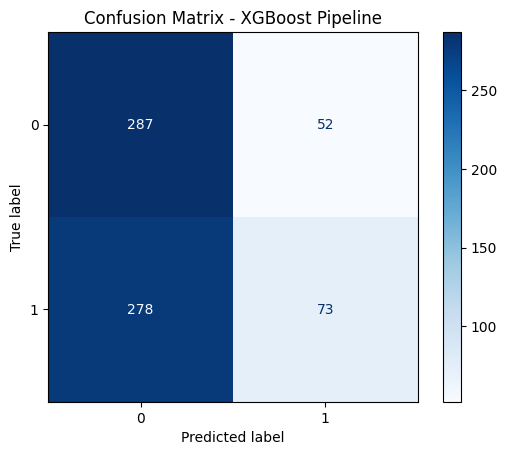


Interprétation rapide:
- Accuracy donne la performance globale.
- Precision mesure la fiabilité des signaux haussiers prédits.
- Recall mesure la capacité à capturer les hausses réelles.
- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.


In [46]:
# ========================
# 9) Métriques et analyse
# ========================

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost Pipeline")
plt.show()

print("\nInterprétation rapide:")
print("- Accuracy donne la performance globale.")
print("- Precision mesure la fiabilité des signaux haussiers prédits.")
print("- Recall mesure la capacité à capturer les hausses réelles.")
print("- F1 équilibre precision et recall, utile en cas de classes déséquilibrées.")

In [ ]:
# =========================================
# 10) Tuning optionnel avec TimeSeriesSplit
# =========================================

RUN_TUNING = False  # Mettre à True pour lancer la recherche

if RUN_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)

    param_distributions = {
        "pca__n_components": [5, 8, 10, 12],
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
        "model__learning_rate": [0.01, 0.03, 0.05],
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="f1",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    random_search.fit(X_train, y_train)
    print("Meilleurs paramètres:")
    print(random_search.best_params_)
    print("Meilleur score CV (f1):", random_search.best_score_)

    # On remplace le pipeline de base par le meilleur pipeline trouvé
    pipeline = random_search.best_estimator_

    # Ré-entraînement implicite déjà fait par RandomizedSearchCV sur tous les folds,
    # mais on recalcule les prédictions sur test pour comparer proprement.
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\nMetrics test après tuning:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
else:
    print("Tuning non lancé (RUN_TUNING=False).")

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Meilleurs paramètres:
{'pca__n_components': 10, 'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}
Meilleur score CV (f1): 0.5891880037147379

Metrics test après tuning:
Accuracy : 0.5043
Precision: 0.5419
Recall   : 0.3407
F1-score : 0.4184


In [48]:
# ==========================
# 11) Sauvegarde du pipeline
# ==========================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "xgb_pipeline_2D.pkl")

with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Pipeline sauvegardé dans: {model_path}")

Pipeline sauvegardé dans: ../models/xgb_pipeline_2D.pkl


In [49]:
# Load the model from the pickle file
#model_path = os.path.join(ROOT_PATH, 'models', 'best_model_2D.pkl')

#with open(model_path, 'rb') as file:
#     model = pickle.load(file)


In [50]:
df.tail()

,Date,Open,High,Low,Close,Volume,target
3645,2026-04-17,75164.039062,78320.679688,74558.601562,77126.875000,54137194839,0.0
3646,2026-04-18,77136.046875,77416.703125,75504.945312,75726.210938,26014416776,1.0
3647,2026-04-19,75723.695312,76243.093750,73802.382812,73856.351562,30931515195,1.0
3648,2026-04-20,73854.250000,76575.359375,73775.570312,75872.523438,39674447916,0.0
3649,2026-04-21,75872.828125,76881.476562,74852.671875,76352.773438,36453522626,0.0


In [51]:
# =========================================================
# 7bis) Pipeline avec modèle linéaire de classification
# =========================================================

feature_transformer = FunctionTransformer(build_technical_features, validate=False)

linear_clf = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    #class_weight="balanced"  # utile si classes un peu déséquilibrées
)

linear_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_transformer),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("model", linear_clf),
    ]
)

print("Pipeline linéaire :")
print(linear_pipeline)

Pipeline linéaire :
Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function build_technical_features at 0x7eaec0d6d800>)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])


In [52]:
# ==========================================
# 8bis) Entraînement du modèle linéaire
# ==========================================

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)
y_proba_linear = linear_pipeline.predict_proba(X_test)[:, 1]

print("Entraînement du pipeline linéaire terminé.")

Entraînement du pipeline linéaire terminé.



===== Résultats Logistic Regression =====
Accuracy : 0.5043
Precision: 0.5421
Recall   : 0.1652
F1-score : 0.2533

Classification report:

              precision    recall  f1-score   support

           0     0.4974    0.8555    0.6291       339
           1     0.5421    0.1652    0.2533       351

    accuracy                         0.5043       690
   macro avg     0.5197    0.5103    0.4412       690
weighted avg     0.5201    0.5043    0.4379       690



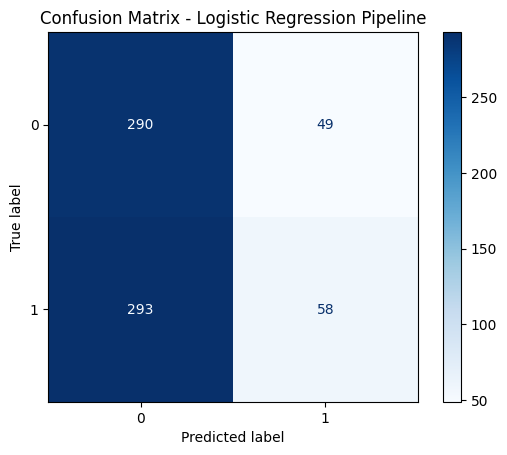

In [53]:
# ==========================================
# 9bis) Métriques du modèle linéaire
# ==========================================

acc_linear = accuracy_score(y_test, y_pred_linear)
prec_linear = precision_score(y_test, y_pred_linear, zero_division=0)
rec_linear = recall_score(y_test, y_pred_linear, zero_division=0)
f1_linear = f1_score(y_test, y_pred_linear, zero_division=0)

print("\n===== Résultats Logistic Regression =====")
print(f"Accuracy : {acc_linear:.4f}")
print(f"Precision: {prec_linear:.4f}")
print(f"Recall   : {rec_linear:.4f}")
print(f"F1-score : {f1_linear:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_linear, digits=4))

cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Pipeline")
plt.show()

In [54]:
# ==========================================
# 11bis) Sauvegarde du pipeline linéaire
# ==========================================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

linear_model_path_2 = os.path.join(model_dir, "average_linear_pipeline.pkl")
average_linear_pipeline = linear_pipeline  # <-- A adapter si on veut sauvegarder un autre pipeline linéaire (ex: best_linear_pipeline après tuning)
with open(linear_model_path_2, "wb") as f:
    pickle.dump(average_linear_pipeline, f)

print(f"Pipeline linéaire sauvegardé dans : {linear_model_path_2}")

Pipeline linéaire sauvegardé dans : ../models/average_linear_pipeline.pkl


Fitting 4 folds for each of 20 candidates, totalling 80 fits

===== Meilleurs paramètres Logistic Regression =====
{'pca__n_components': 0.9, 'model__solver': 'saga', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': np.float64(0.003359818286283781)}
Meilleur score CV (f1): 0.6932938019309227

===== Metrics test après tuning =====
Accuracy : 0.5087
Precision: 0.5087
Recall   : 1.0000
F1-score : 0.6744

Classification report après tuning:

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       339
           1     0.5087    1.0000    0.6744       351

    accuracy                         0.5087       690
   macro avg     0.2543    0.5000    0.3372       690
weighted avg     0.2588    0.5087    0.3430       690



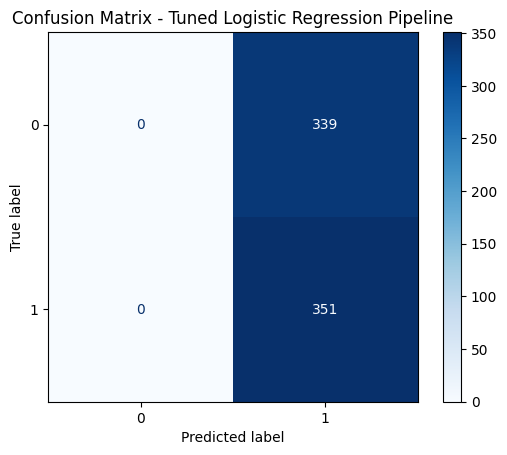

In [55]:
# ===================================================
# 10bis) Tuning du modèle linéaire avec TimeSeriesCV
# ===================================================

RUN_LINEAR_TUNING = True

if RUN_LINEAR_TUNING:
    tscv = TimeSeriesSplit(n_splits=4)

    param_distributions_linear = {
        "pca__n_components": [0.80, 0.90, 0.95, 0.99],
        "model__C": np.logspace(-3, 2, 20),
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear", "saga"],
        "model__class_weight": [None, "balanced"],
    }

    random_search_linear = RandomizedSearchCV(
        estimator=linear_pipeline,
        param_distributions=param_distributions_linear,
        n_iter=20,
        scoring="f1",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    random_search_linear.fit(X_train, y_train)

    print("\n===== Meilleurs paramètres Logistic Regression =====")
    print(random_search_linear.best_params_)
    print("Meilleur score CV (f1):", random_search_linear.best_score_)

    best_linear_pipeline = random_search_linear.best_estimator_

    y_pred_linear = best_linear_pipeline.predict(X_test)
    y_proba_linear = best_linear_pipeline.predict_proba(X_test)[:, 1]

    acc_linear = accuracy_score(y_test, y_pred_linear)
    prec_linear = precision_score(y_test, y_pred_linear, zero_division=0)
    rec_linear = recall_score(y_test, y_pred_linear, zero_division=0)
    f1_linear = f1_score(y_test, y_pred_linear, zero_division=0)

    print("\n===== Metrics test après tuning =====")
    print(f"Accuracy : {acc_linear:.4f}")
    print(f"Precision: {prec_linear:.4f}")
    print(f"Recall   : {rec_linear:.4f}")
    print(f"F1-score : {f1_linear:.4f}")

    print("\nClassification report après tuning:\n")
    print(classification_report(y_test, y_pred_linear, digits=4))

    cm_linear = confusion_matrix(y_test, y_pred_linear)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix - Tuned Logistic Regression Pipeline")
    plt.show()

else:
    print("Tuning linéaire non lancé (RUN_LINEAR_TUNING=False).")
    best_linear_pipeline = linear_pipeline

In [56]:
# ==========================================
# 11bis) Sauvegarde du pipeline linéaire
# ==========================================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

linear_model_path = os.path.join(model_dir, "last_linear_pipeline.pkl")

with open(linear_model_path, "wb") as f:
    pickle.dump(best_linear_pipeline, f)

print(f"Pipeline linéaire sauvegardé dans : {linear_model_path}")

Pipeline linéaire sauvegardé dans : ../models/last_linear_pipeline.pkl


In [57]:
comparison_df = pd.DataFrame({
    "model": ["xgboost", "logistic_regression"],
    "accuracy": [acc, acc_linear],
    "precision": [prec, prec_linear],
    "recall": [rec, rec_linear],
    "f1_score": [f1, f1_linear],
})

display(comparison_df)

,model,accuracy,precision,recall,f1_score
0,xgboost,0.521739,0.584000,0.207977,0.306723
1,logistic_regression,0.508696,0.508696,1.000000,0.674352


I0000 00:00:1776953495.831318   35550 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776953495.857465   35550 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776953499.067763   35550 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776953504.334714   35550 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Imports OK
Shape du dataset: (3650, 6)

Aperçu des données:


,Date,Open,High,Low,Close,Volume
0,2016-04-24,450.559998,460.145996,448.928009,458.554993,68198400
1,2016-04-25,459.121002,466.619995,453.592010,461.425995,87091800
2,2016-04-26,461.648010,467.964996,461.621002,466.088989,78971904
3,2016-04-27,466.261993,467.079010,444.134003,444.687012,93564896
4,2016-04-28,445.037994,449.550995,436.649994,449.010986,74064704



Types de colonnes:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Valeurs manquantes par colonne:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
Open,3650.0,3.256635e+04,3.257906e+04,4.377930e+02,6.960144e+03,2.014414e+04,5.208554e+04,1.247521e+05
High,3650.0,3.321749e+04,3.312038e+04,4.434270e+02,7.168180e+03,2.044410e+04,5.328055e+04,1.261981e+05
Low,3650.0,3.187511e+04,3.199549e+04,4.366500e+02,6.790648e+03,1.968921e+04,5.084051e+04,1.231960e+05
Close,3650.0,3.258597e+04,3.258216e+04,4.387150e+02,6.969013e+03,2.016011e+04,5.214239e+04,1.247525e+05
Volume,3650.0,2.572554e+10,2.285909e+10,2.851400e+07,6.902335e+09,2.218633e+10,3.709216e+10,3.509679e+11


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5343 - loss: 0.7220 - val_accuracy: 0.4982 - val_loss: 0.6980
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5279 - loss: 0.7049 - val_accuracy: 0.4982 - val_loss: 0.6956
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5626 - loss: 0.6861 - val_accuracy: 0.5456 - val_loss: 0.6900
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ -1s -13746us/step - accuracy: 0.5530 - loss: 0.6905 - val_accuracy: 0.5602 - val_loss: 0.6902
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5649 - loss: 0.6763 - val_accuracy: 0.5675 - val_loss: 0.6881
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5727 - loss: 0.6665 - val_accuracy: 0.5712 - val_loss: 0.6902
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5859 - loss: 0.6656 - val_accuracy: 0.5547 - val_loss: 0.6938
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5905 - loss: 0.6559 - val_accuracy: 0.5420 - va

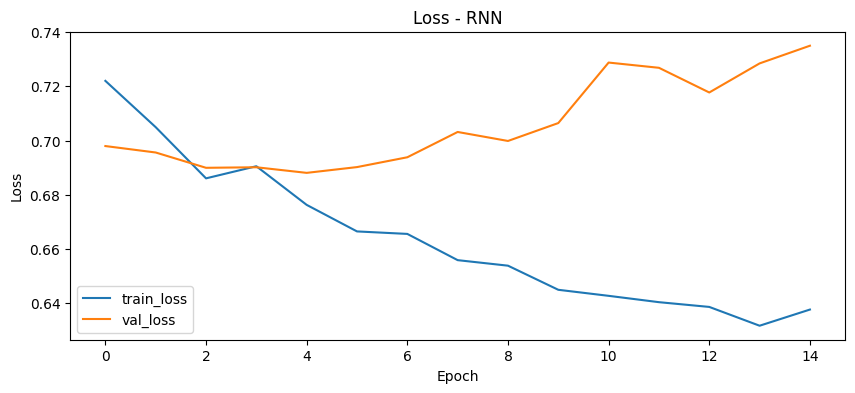

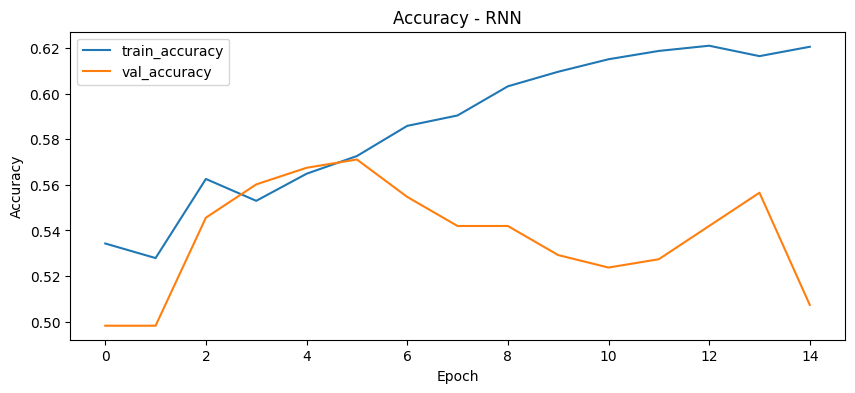

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== Résultats RNN =====
Accuracy : 0.4776
Precision: 0.6250
Recall   : 0.0559
F1-score : 0.1026

Classification report:

              precision    recall  f1-score   support

           0     0.4702    0.9615    0.6316       312
           1     0.6250    0.0559    0.1026       358

    accuracy                         0.4776       670
   macro avg     0.5476    0.5087    0.3671       670
weighted avg     0.5529    0.4776    0.3489       670



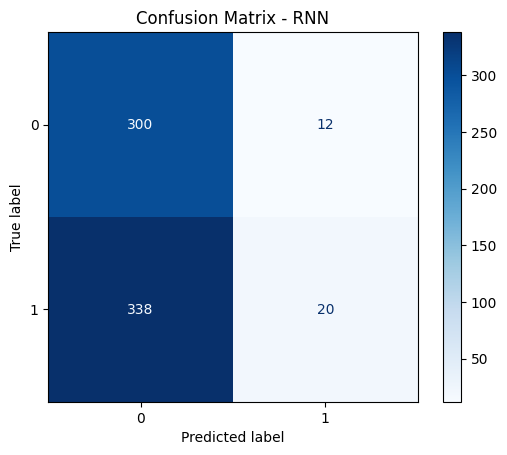


Interprétation rapide:
- Accuracy donne la performance globale.
- Precision mesure la fiabilité des signaux haussiers prédits.
- Recall mesure la capacité à capturer les hausses réelles.
- F1 équilibre precision et recall, utile si les classes sont déséquilibrées.

Modèle RNN sauvegardé dans : ../models/rnn_model.keras
Préprocessing sauvegardé dans : ../models/rnn_preprocessing_2D.pkl

Reload OK
lookback rechargé: 20
feature_columns rechargées: ['slope_ma200_5d', 'ma50_level', 'dist_spot_ma30', 'dist_spot_ma50', 'ma10_200_crossover', 'rsi14', 'vol_ratio_30_200', 'ret_1d', 'mom_5d', 'mom_10d', 'mom_20d', 'daily_range', 'dist_spot_ma200', 'slope_ma50_5d', 'volume_change_1d', 'rolling_vol_20']


In [ ]:
# =============================
# 1) Imports et configuration
# =============================

import os
import pickle
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

# Pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Imports OK")

# =====================================
# 2) Chargement des données depuis CSV
# =====================================

CSV_PATH = "../data_folder/cache/BTC-USD.csv"  # <-- A adapter

# Lecture CSV
raw_df = pd.read_csv(CSV_PATH)

# Copie de travail
df = raw_df.copy()

# Si la colonne date existe, on la convertit
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date").reset_index(drop=True)
    df = df.set_index("date")
    df = df.sort_index()

print("Shape du dataset:", df.shape)

if isinstance(df.index, pd.DatetimeIndex):
    print("Période:", df.index.min(), "->", df.index.max())

# ======================================
# 3) Aperçu, types et valeurs manquantes
# ======================================

print("\nAperçu des données:")
display(df.head())

print("\nTypes de colonnes:")
print(df.dtypes)

print("\nValeurs manquantes par colonne:")
print(df.isna().sum())

print("\nStatistiques descriptives:")
display(df.describe().T)

# =====================
# 4) Création de target
# =====================

horizon = 2  # Nombre de jours dans le futur

# Si close futur > close actuel => target=1, sinon 0
df["target"] = (df["Close"].shift(-horizon) > df["Close"]).astype(float)

print("Distribution target (avant dropna final):")
print(df["target"].value_counts(dropna=False))

# ==============================================
# 5) Fonctions de features techniques
# ==============================================

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """Calcul simple du RSI."""
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def build_technical_features(X: pd.DataFrame) -> pd.DataFrame:
    """
    Transforme un DataFrame OHLCV brut en features techniques.
    Aucune fuite d'information future.
    """
    data = X.copy()
    data = data.sort_index()

    # MAs
    data["ma10"] = data["Close"].rolling(10).mean()
    data["ma30"] = data["Close"].rolling(30).mean()
    data["ma50"] = data["Close"].rolling(50).mean()
    data["ma200"] = data["Close"].rolling(200).mean()

    # Retours quotidiens
    daily_ret = data["Close"].pct_change()

    # Features principales
    data["slope_ma200_5d"] = data["ma200"].pct_change(5)
    data["ma50_level"] = data["ma50"]
    data["dist_spot_ma30"] = (data["Close"] / (data["ma30"] + 1e-12)) - 1
    data["dist_spot_ma50"] = (data["Close"] / (data["ma50"] + 1e-12)) - 1
    data["ma10_200_crossover"] = (data["ma10"] / (data["ma200"] + 1e-12)) - 1
    data["rsi14"] = compute_rsi(data["Close"], window=14)

    vol30 = daily_ret.rolling(30).std()
    vol200 = daily_ret.rolling(200).std()
    data["vol_ratio_30_200"] = vol30 / (vol200 + 1e-12)

    # Features additionnelles
    data["ret_1d"] = daily_ret
    data["mom_5d"] = data["Close"].pct_change(5)
    data["mom_10d"] = data["Close"].pct_change(10)
    data["mom_20d"] = data["Close"].pct_change(20)
    data["daily_range"] = (data["High"] - data["Low"]) / (data["Close"] + 1e-12)
    data["dist_spot_ma200"] = (data["Close"] / (data["ma200"] + 1e-12)) - 1
    data["slope_ma50_5d"] = data["ma50"].pct_change(5)
    data["volume_change_1d"] = data["Volume"].pct_change(1)
    data["rolling_vol_20"] = daily_ret.rolling(20).std()

    feature_cols = [
        "slope_ma200_5d",
        "ma50_level",
        "dist_spot_ma30",
        "dist_spot_ma50",
        "ma10_200_crossover",
        "rsi14",
        "vol_ratio_30_200",
        "ret_1d",
        "mom_5d",
        "mom_10d",
        "mom_20d",
        "daily_range",
        "dist_spot_ma200",
        "slope_ma50_5d",
        "volume_change_1d",
        "rolling_vol_20",
    ]

    return data[feature_cols]

# ==================================================
# 6) Construction de X/y et split temporel explicite
# ==================================================

raw_feature_cols = ["Open", "High", "Low", "Close", "Volume"]

X_raw = df[raw_feature_cols].copy()
y_raw = df["target"].copy()

# Features techniques
X_feat = build_technical_features(X_raw)

# On garde uniquement les lignes valides
valid_mask = X_feat.notna().all(axis=1) & y_raw.notna()
X_feat_clean = X_feat.loc[valid_mask].copy()
y_clean = y_raw.loc[valid_mask].astype(int).copy()

print("Nombre d'observations valides:", len(X_feat_clean))
print("Distribution target finale:")
print(y_clean.value_counts(normalize=True).rename("ratio"))

# Split chronologique 80 / 20
split_ratio = 0.8
split_idx = int(len(X_feat_clean) * split_ratio)

X_train_df = X_feat_clean.iloc[:split_idx].copy()
X_test_df = X_feat_clean.iloc[split_idx:].copy()
y_train = y_clean.iloc[:split_idx].copy()
y_test = y_clean.iloc[split_idx:].copy()

print("\nShapes avant séquences:")
print("X_train_df:", X_train_df.shape, "| y_train:", y_train.shape)
print("X_test_df :", X_test_df.shape, "| y_test :", y_test.shape)

if isinstance(X_feat_clean.index, pd.DatetimeIndex):
    print("\nPériodes:")
    print("Train:", X_train_df.index.min(), "->", X_train_df.index.max())
    print("Test :", X_test_df.index.min(), "->", X_test_df.index.max())

# ==========================================================
# 7) Imputation + scaling (fit train uniquement, puis transform)
# ==========================================================

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train_df)
X_test_imputed = imputer.transform(X_test_df)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nPréprocessing terminé.")
print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

# ==========================================
# 8) Création des séquences pour le RNN
# ==========================================

LOOKBACK = 20  # nombre de pas de temps utilisés pour prédire


def create_sequences(X, y, lookback):
    """
    Construit des séquences 3D pour le RNN.
    X: array 2D (n_samples, n_features)
    y: array 1D (n_samples,)

    Retour:
    X_seq: (n_sequences, lookback, n_features)
    y_seq: (n_sequences,)
    """
    X_seq, y_seq = [], []

    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.values,
    LOOKBACK
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test.values,
    LOOKBACK
)

print("\nShapes après création des séquences:")
print("X_train_seq:", X_train_seq.shape, "| y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape, "| y_test_seq :", y_test_seq.shape)

# ==========================================
# 9) Construction du modèle RNN
# ==========================================

n_features = X_train_seq.shape[2]

rnn_model = Sequential([
    SimpleRNN(
        units=32,
        activation="tanh",
        input_shape=(LOOKBACK, n_features),
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nRésumé du modèle RNN:")
rnn_model.summary()

# ======================
# 10) Entraînement modèle
# ======================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Entraînement terminé.")

# ============================
# 11) Courbes d'entraînement
# ============================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Loss - RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Accuracy - RNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ========================
# 12) Prédictions et analyse
# ========================

# Probabilités
y_proba_rnn = rnn_model.predict(X_test_seq).ravel()

# Classes prédites
threshold = 0.5
y_pred_rnn = (y_proba_rnn >= threshold).astype(int)

acc_rnn = accuracy_score(y_test_seq, y_pred_rnn)
prec_rnn = precision_score(y_test_seq, y_pred_rnn, zero_division=0)
rec_rnn = recall_score(y_test_seq, y_pred_rnn, zero_division=0)
f1_rnn = f1_score(y_test_seq, y_pred_rnn, zero_division=0)

print("\n===== Résultats RNN =====")
print(f"Accuracy : {acc_rnn:.4f}")
print(f"Precision: {prec_rnn:.4f}")
print(f"Recall   : {rec_rnn:.4f}")
print(f"F1-score : {f1_rnn:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test_seq, y_pred_rnn, digits=4))

cm_rnn = confusion_matrix(y_test_seq, y_pred_rnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - RNN")
plt.show()

print("\nInterprétation rapide:")
print("- Accuracy donne la performance globale.")
print("- Precision mesure la fiabilité des signaux haussiers prédits.")
print("- Recall mesure la capacité à capturer les hausses réelles.")
print("- F1 équilibre precision et recall, utile si les classes sont déséquilibrées.")

# ==========================================
# 13) Sauvegarde du modèle et du preprocessing
# ==========================================

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Sauvegarde du modèle Keras
rnn_model_path = os.path.join(model_dir, "rnn_model_2D.keras")
rnn_model.save(rnn_model_path)

# Sauvegarde des objets de preprocessing
preprocessing_path = os.path.join(model_dir, "rnn_preprocessing_2D.pkl")

rnn_artifacts = {
    "imputer": imputer,
    "scaler": scaler,
    "lookback": LOOKBACK,
    "feature_columns": list(X_feat_clean.columns),
    "horizon": horizon,
}

with open(preprocessing_path, "wb") as f:
    pickle.dump(rnn_artifacts, f)

print(f"\nModèle RNN sauvegardé dans : {rnn_model_path}")
print(f"Préprocessing sauvegardé dans : {preprocessing_path}")

# ==========================================
# 14) Exemple de rechargement
# ==========================================

loaded_rnn_model = load_model(rnn_model_path)

with open(preprocessing_path, "rb") as f:
    loaded_artifacts = pickle.load(f)

print("\nReload OK")
print("lookback rechargé:", loaded_artifacts["lookback"])
print("feature_columns rechargées:", loaded_artifacts["feature_columns"])

In [59]:
def predict_from_df(df, model, imputer, scaler, lookback):

    # features
    X_feat = build_technical_features(df)

    # drop NaN
    X_feat = X_feat.dropna()

    # preprocess
    X_imputed = imputer.transform(X_feat)
    X_scaled = scaler.transform(X_imputed)

    # séquences
    X_seq, _ = create_sequences(X_scaled, np.zeros(len(X_scaled)), lookback)

    # prédiction
    y_proba = model.predict(X_seq).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    return y_pred, y_proba